<a href="https://colab.research.google.com/github/Adr1an12/Adr1an12/blob/main/a_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

In [2]:
from google.colab import files
import pandas as pd

# Upload do arquivo
uploaded = files.upload()

df = pd.read_csv("dataset_emprestimo_aprovacao.csv")

print("Primeiras linhas:")
print(df.head())

Saving dataset_emprestimo_aprovacao.csv to dataset_emprestimo_aprovacao.csv
Primeiras linhas:
   renda_mensal  score_credito  dividas_ativas  emprestimo_aprovado
0       5493.43            480               4                    0
1       4223.47            600               5                    0
2       5795.38            609               5                    1
3       7546.06            554               1                    1
4       4031.69            631               0                    1


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   renda_mensal         100 non-null    float64
 1   score_credito        100 non-null    int64  
 2   dividas_ativas       100 non-null    int64  
 3   emprestimo_aprovado  100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB
None


In [4]:
print(df.describe())

       renda_mensal  score_credito  dividas_ativas  emprestimo_aprovado
count    100.000000     100.000000      100.000000            100.00000
mean    4596.775500     651.220000        1.990000              0.79000
std     2623.031756     109.977921        1.690705              0.40936
min     1200.000000     420.000000        0.000000              0.00000
25%     3274.882500     553.500000        1.000000              1.00000
50%     4312.340000     660.000000        2.000000              1.00000
75%     5541.177500     725.500000        3.000000              1.00000
max    19546.000000     900.000000        8.000000              1.00000


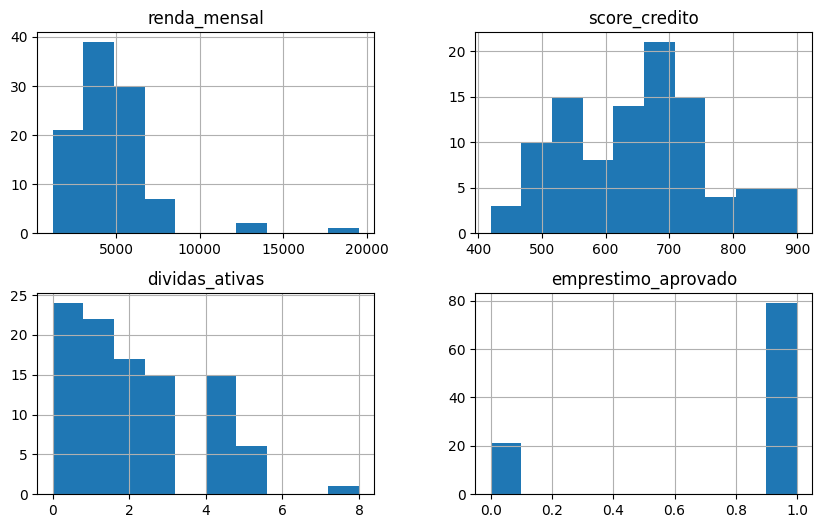

In [5]:
df.hist(figsize=(10,6))
plt.show()

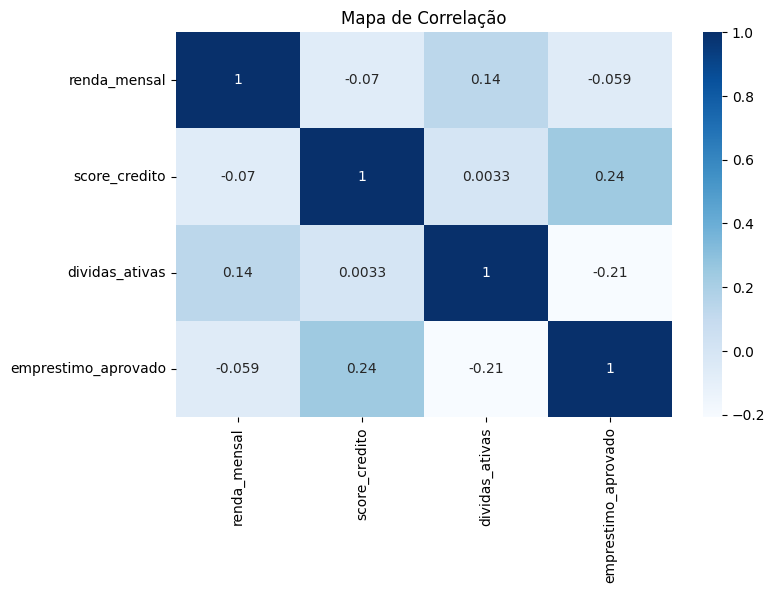

In [6]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Mapa de Correlação")

plt.show()

In [7]:
X = df[[
    "renda_mensal",
    "score_credito",
    "dividas_ativas"
]]

y = df["emprestimo_aprovado"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 70
Teste: 30


In [9]:
modelo = LogisticRegression()

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [10]:
y_pred = modelo.predict(X_test)

print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


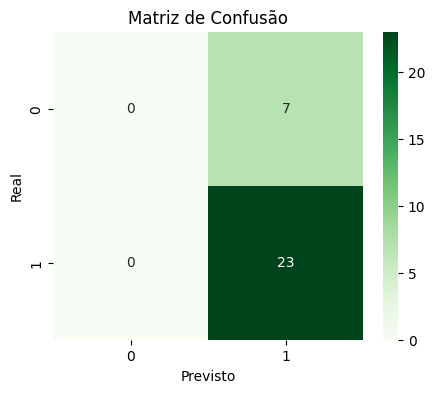

In [11]:
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

In [12]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy do modelo:")
print(acc)

Accuracy do modelo:
0.7666666666666667


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.77      1.00      0.87        23

    accuracy                           0.77        30
   macro avg       0.38      0.50      0.43        30
weighted avg       0.59      0.77      0.67        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
coeficientes = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": modelo.coef_[0]
})

print(coeficientes)

         Variável  Coeficiente
0    renda_mensal    -0.000015
1   score_credito     0.003879
2  dividas_ativas    -0.245250


In [15]:
novo_cliente = [[5000, 700, 1]]

previsao = modelo.predict(novo_cliente)

print("Resultado da previsão:")

if previsao[0] == 1:
    print("Empréstimo aprovado")
else:
    print("Empréstimo negado")

Resultado da previsão:
Empréstimo aprovado


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [16]:
print("""
Conclusão:

O modelo de regressão logística conseguiu analisar os dados
dos clientes e prever a aprovação de empréstimos com boa precisão.

As variáveis renda mensal, score de crédito e quantidade
de dívidas ativas influenciam diretamente na decisão final.
""")


Conclusão:

O modelo de regressão logística conseguiu analisar os dados
dos clientes e prever a aprovação de empréstimos com boa precisão.

As variáveis renda mensal, score de crédito e quantidade
de dívidas ativas influenciam diretamente na decisão final.

